In [56]:
import cv2
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation, RecordVideo
from gymnasium.wrappers.vector import RecordEpisodeStatistics
from gymnasium.vector import SyncVectorEnv
from gymnasium import spaces

import numpy as np

import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

import time
import matplotlib.pyplot as plt

In [ ]:
env_id = "ALE/MsPacman-v5"
train_video_dir = f"../data/ppo/fine-tuning-v6"
train_episodes = 500
num_steps = 512
num_envs = 16
frameskips = 4
stack_size = 8

In [58]:
class ResizeRender(gym.Wrapper):
    def render(self):
        frame = self.env.render()

        return cv2.resize(
            frame,
            (640, 840),
            interpolation=cv2.INTER_NEAREST
        )
        
class RemoveNoopWrapper(gym.ActionWrapper):
    def __init__(self, env):
        super().__init__(env)
        
        self.action_map = {
            0: 1, # UP
            1: 2, # RIGHT
            2: 3, # LEFT
            3: 4, # DOWN
        }
        
        self.action_space = spaces.Discrete(
            len(self.action_map)
        )
        
    def action(self, action):
        return self.action_map[action]

In [59]:
def make_env(env_id: str, idx: int, capture_video: bool):
    def thunk():
        env = gym.make(env_id, frameskip=1, render_mode="rgb_array")
        
        env = AtariPreprocessing(env, noop_max=30, screen_size=(84, 84), scale_obs=True, frame_skip=frameskips, terminal_on_life_loss=False)
        env = FrameStackObservation(env, stack_size=stack_size)
        # env = RemoveNoopWrapper(env)
        
        if capture_video and idx == 0:
            env = ResizeRender(env)
            env = RecordVideo(env, train_video_dir, episode_trigger=lambda episode_id: episode_id % 10 == 0)
        return env
    return thunk

In [60]:
gym.register_envs(ale_py)

envs = SyncVectorEnv([make_env(env_id, idx, capture_video=True) for idx in range(num_envs)])
envs = RecordEpisodeStatistics(envs)

c:\Users\vladi\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at d:\Study\Projects\pacman-agent\data\ppo\fine-tuning-v6 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [61]:
# action_size = envs.single_action_space.n
# action_size
action_size = np.int64(5)

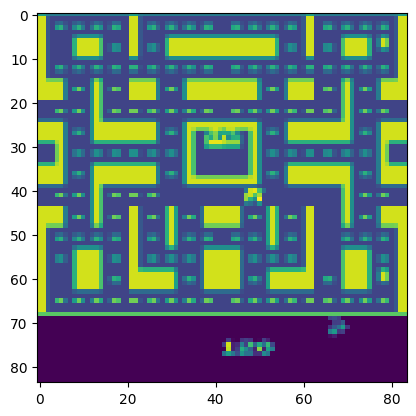

In [62]:
obs, _ = envs.reset(seed=42)
obs[0][0]

for i in range(300):
    obs, *_ = envs.step(envs.action_space.sample())

plt.imshow(obs[0][0])

In [63]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
device

'cuda'

In [64]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class PacmanAgent(nn.Module):
    def __init__(self, n_hid, n_out):
        super().__init__()
        self.network = nn.Sequential(
            layer_init(nn.Conv2d(stack_size, 32, kernel_size=8, stride=4)),
            nn.ReLU(),
            
            layer_init(nn.Conv2d(32, 64, kernel_size=4, stride=2)),
            nn.ReLU(),         
               
            layer_init(nn.Conv2d(64, 64, kernel_size=3, stride=1)),
            nn.ReLU(),
            
            nn.Flatten(),
            layer_init(nn.Linear(64 * 7 * 7, n_hid)),
            nn.ReLU(),  
        )
        
        self.actor = layer_init(nn.Linear(n_hid, n_out), std=0.01)
        self.critic = layer_init(nn.Linear(n_hid, 1), std=1)                

    def get_value(self, x):
        return self.critic(self.network(x))

    def get_action_and_value(self, x, action=None):
        hidden = self.network(x)
        logits = self.actor(hidden)
        probs = torch.distributions.Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(hidden)
    
def train(
    envs,
    model,
    optimizer,
    updates,
    update_epochs,
    num_steps,
    target_kl = 0.03,
    mini_batch_size = 64,
    gae_lambda = 0.95,
    clip_coef = 0.2,
    ent_coef = 0.01,
    vf_coef = 0.5,
    max_grad_norm = 0.5,
    norm_advantages = False,
    clip_vloss = False,
    lr_decay = False,
    gamma = 0.999,
    initial_lr = 1e-3,
    min_lr = 1e-5
):
    
    total_timesteps = updates * num_steps * num_envs
    
    writer = SummaryWriter(f"runs/pacman-fine-tune-v6")
    
    batch_size = num_steps * num_envs
    
    obs = torch.zeros((num_steps, num_envs) + envs.single_observation_space.shape).to(device)
    actions = torch.zeros((num_steps, num_envs) + envs.single_action_space.shape, dtype=torch.long).to(device)
    logprobs = torch.zeros((num_steps, num_envs)).to(device)
    rewards = torch.zeros((num_steps, num_envs)).to(device)
    dones = torch.zeros((num_steps, num_envs)).to(device)
    values = torch.zeros((num_steps, num_envs)).to(device)
    
    global_step = 0
    next_obs, _ = envs.reset()
    next_obs = torch.Tensor(next_obs).to(device)
    next_done = torch.zeros(num_envs).to(device)
    start_time = time.time()
    
    for episode in range(1, updates + 1):      
        total_reward = 0
        
        if lr_decay:
            frac = max(
                0.0,
                1.0 - global_step / total_timesteps
            )

            lrnow = min_lr + frac * (initial_lr - min_lr)

            optimizer.param_groups[0]["lr"] = lrnow
        
        for step in range(0, num_steps):
            global_step += num_envs
            obs[step] = next_obs
            dones[step] = next_done
            
            with torch.no_grad():
                action, logprob, _, value = model.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action
            logprobs[step] = logprob
            
            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
            next_done = np.logical_or(terminations, truncations)
            rewards[step] = torch.tensor(reward).to(device).view(-1)
            total_reward += float(reward.mean())
            next_obs, next_done = torch.Tensor(next_obs).to(device), torch.tensor(next_done, dtype=torch.float32).to(device)
            
            if "final_info" in infos:
                for info in infos["final_info"]:
                    if info and "episode" in info:
                        print(f"global_step={global_step}, episodic_return={info['episode']['r']}")
                        writer.add_scalar("charts/episodic_return", info["episode"]["r"], global_step)
                        writer.add_scalar("charts/episodic_length", info["episode"]["l"], global_step)
                        
        with torch.no_grad():
            next_value = model.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards).to(device)
            lastgaelam = 0
            for t in reversed(range(num_steps)):
                if t == num_steps - 1:
                    next_nonterminal = 1.0 - next_done
                    next_values = next_value
                else:
                    next_nonterminal = 1.0 - dones[t + 1]
                    next_values = values[t + 1]
                delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
                advantages[t] = lastgaelam = delta + gamma * gae_lambda * next_nonterminal * lastgaelam
            returns = advantages + values
         
        b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
        b_advanatages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values.reshape(-1)
        
        b_inds = np.arange(batch_size)
        clipfracs = []
        for epoch in range(update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, batch_size, mini_batch_size):
                end = start + mini_batch_size
                mb_inds = b_inds[start:end]
                
                _, newlogprob, entropy, newvalue = model.get_action_and_value(b_obs[mb_inds], b_actions.long()[mb_inds])
                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()
                
                with torch.no_grad():
                    old_approx_kl = (-logratio).mean()
                    approx_kl = ((ratio - 1) - logratio).mean()
                    clipfracs += [((ratio - 1.0).abs() > clip_coef).float().mean().item()]
                    
                mb_advantages = b_advanatages[mb_inds]
                if norm_advantages: 
                    mb_advantages = (mb_advantages-mb_advantages.mean()) / (mb_advantages.std() + 1e-8)
                
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()
                
                new_value = newvalue.view(-1)

                if clip_vloss:
                    v_loss_unclipped = (
                        new_value - b_returns[mb_inds]
                    ) ** 2

                    v_clipped = (
                        b_values[mb_inds]
                        + torch.clamp(
                            new_value - b_values[mb_inds],
                            -clip_coef,
                            clip_coef,
                        )
                    )

                    v_loss_clipped = (
                        v_clipped - b_returns[mb_inds]
                    ) ** 2

                    v_loss_max = torch.max(
                        v_loss_unclipped,
                        v_loss_clipped
                    )

                    v_loss = 0.5 * v_loss_max.mean()

                else:
                    v_loss = 0.5 * (
                        (new_value - b_returns[mb_inds]) ** 2
                    ).mean()
                    
                entropy_loss = entropy.mean()
                loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()
                
            if target_kl is not None and approx_kl > target_kl:
                break
            
        y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
        var_y = np.var(y_true)
        explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y
        
        writer.add_scalar("charts/learning_rate", optimizer.param_groups[0]["lr"], global_step)
        writer.add_scalar("losses/value_loss", v_loss.item(), global_step)
        writer.add_scalar("losses/policy_loss", pg_loss.item(), global_step)
        writer.add_scalar("losses/entropy", entropy_loss.item(), global_step)
        writer.add_scalar("losses/old_approx_kl", old_approx_kl.item(), global_step)
        writer.add_scalar("losses/approx_kl", approx_kl.item(), global_step)
        writer.add_scalar("losses/clipfrac", np.mean(clipfracs), global_step)
        writer.add_scalar("losses/explained_variance", explained_var, global_step)
        writer.add_scalar("charts/mean_rollout_reward", total_reward, global_step) 
        print(f"\rSPS: {int(global_step / (time.time() - start_time))} | episode: {episode} | mean rollout reward: {total_reward} | global_step: {global_step}")
        writer.add_scalar("charts/SPS", int(global_step / (time.time() - start_time)), global_step)
            
    envs.close()
    writer.close()

In [ ]:
agent = PacmanAgent(512, action_size).to(device)
agent.load_state_dict(torch.load("../models/ppo-fine-tuned/pacman-agent-ft-v4.pth"))

lr = 1e-4
optimizer = torch.optim.NAdam(agent.parameters(), lr=lr, eps=1e-5)
optimizer.load_state_dict(torch.load("../models/ppo-fine-tuned/pacman-optimizer-ft-v4.pth"))

for pg in optimizer.param_groups:
    print(f"old pg: {pg['lr']}")
    # lr = pg['lr']
    pg['lr'] = lr
    print(f"new pg: {pg['lr']}")

old pg: 0.0001
new pg: 0.0001


In [66]:
train(
    envs=envs,
    model=agent,
    optimizer=optimizer,
    updates=train_episodes,
    
    update_epochs=6,
    num_steps=num_steps,
    target_kl=0.03,
    mini_batch_size=64,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=0.02,
    vf_coef=0.5,
    max_grad_norm=0.5,
    
    norm_advantages=True,
    clip_vloss=True,
    lr_decay=False,
    
    gamma=0.999,
    initial_lr=lr,
    min_lr=9e-5
)

SPS: 659 | episode: 1 | mean rollout reward: 1652.5 | global_step: 8192
SPS: 678 | episode: 2 | mean rollout reward: 776.25 | global_step: 16384
SPS: 676 | episode: 3 | mean rollout reward: 608.75 | global_step: 24576
SPS: 692 | episode: 4 | mean rollout reward: 1249.375 | global_step: 32768
SPS: 664 | episode: 5 | mean rollout reward: 635.625 | global_step: 40960
SPS: 668 | episode: 6 | mean rollout reward: 1233.125 | global_step: 49152
SPS: 670 | episode: 7 | mean rollout reward: 1530.0 | global_step: 57344
SPS: 654 | episode: 8 | mean rollout reward: 1266.25 | global_step: 65536
SPS: 673 | episode: 9 | mean rollout reward: 1444.375 | global_step: 73728
SPS: 688 | episode: 10 | mean rollout reward: 1533.125 | global_step: 81920
SPS: 683 | episode: 11 | mean rollout reward: 1229.375 | global_step: 90112
SPS: 679 | episode: 12 | mean rollout reward: 975.625 | global_step: 98304
SPS: 685 | episode: 13 | mean rollout reward: 1671.25 | global_step: 106496
SPS: 685 | episode: 14 | mean rol

In [67]:
torch.save(agent.state_dict(), "../models/ppo-fine-tuned/pacman-agent-ft-v6.pth")
torch.save(optimizer.state_dict(), "../models/ppo-fine-tuned/pacman-optimizer-ft-v6.pth")